# Churn Analysis — Tidemill API vs Stripe

Compare logo churn and revenue churn from the Tidemill engine with Stripe subscription data.

In [1]:
import os
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import requests
import stripe

warnings.filterwarnings("ignore", "Unverified HTTPS")

API = os.environ.get("TIDEMILL_API", "http://localhost:8000")
API_KEY = os.environ.get("TIDEMILL_API_KEY", "")
stripe.api_key = os.environ["STRIPE_API_KEY"]

START, END = "2025-09-01", "2026-03-31"
plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})

_session = requests.Session()
if API_KEY:
    _session.headers["Authorization"] = f"Bearer {API_KEY}"


def api_get(path, **params):
    r = _session.get(f"{API}{path}", params=params)
    r.raise_for_status()
    return r.json()

## 1. Logo Churn from Tidemill API

In [2]:
# Churn rate requires customers active BEFORE the period start as denominator.
# Since all data begins in September 2025, we measure churn from October onwards.
CHURN_START = "2025-10-01"

logo_churn = api_get("/api/metrics/churn", start=CHURN_START, end=END, type="logo")
revenue_churn = api_get("/api/metrics/churn", start=CHURN_START, end=END, type="revenue")

print(f"Period: {CHURN_START} → {END}")
print()
print(
    f"Logo churn rate:    {logo_churn * 100:.1f}%"
    if logo_churn is not None
    else "Logo churn rate:    N/A"
)
print(
    f"Revenue churn rate: {revenue_churn * 100:.1f}%"
    if revenue_churn is not None
    else "Revenue churn rate: N/A"
)

# Also show total churned MRR from breakdown
breakdown = api_get("/api/metrics/mrr/breakdown", start=START, end=END)
by_type = {b["movement_type"]: b["amount_base"] for b in breakdown}
print()
print("MRR movements (full period):")
for mt in ["new", "expansion", "reactivation", "contraction", "churn"]:
    amt = by_type.get(mt, 0) / 100
    print(f"  {mt:15s}  ${amt:>10,.2f}")
print(f"  {'net':15s}  ${sum(by_type.values()) / 100:>10,.2f}")

Period: 2025-10-01 → 2026-03-31

Logo churn rate:    22.2%
Revenue churn rate: 21.1%

MRR movements (full period):
  new              $  1,219.33
  expansion        $    116.00
  reactivation     $      0.00
  contraction      $    -58.00
  churn            $   -310.00
  net              $    967.33


## 2. Churn from Stripe (ground truth)

Compute churn using the same methodology as Tidemill:
- **Logo churn** = distinct *customers* who lost ALL subscriptions in the period / customers active at period start
- **Revenue churn** = |churned MRR| / starting MRR

In [3]:
def stripe_mrr_for_sub(sub):
    total = 0
    for item in sub["items"]["data"]:
        price = item["price"]
        qty = item.get("quantity", 1) or 1
        unit_amount = price.get("unit_amount", 0) or 0
        amount = unit_amount * qty
        rec = price.get("recurring") or {}
        interval = rec.get("interval", "month")
        interval_count = rec.get("interval_count", 1) or 1
        if interval == "month":
            total += amount // interval_count
        elif interval == "year":
            total += amount // (12 * interval_count)
    return total


# Collect all subscriptions across test clocks
clock_ids = [c.id for c in stripe.test_helpers.TestClock.list(limit=100).auto_paging_iter()]
all_subs = []
for cid in clock_ids:
    for sub in stripe.Subscription.list(
        limit=100, test_clock=cid, status="all"
    ).auto_paging_iter():
        all_subs.append(sub.to_dict())

df = pd.DataFrame(
    [
        {
            "id": s["id"],
            "customer": s["customer"],
            "status": s["status"],
            "mrr_cents": stripe_mrr_for_sub(s),
            "created_at": datetime.fromtimestamp(s["created"], tz=UTC),
            "canceled_at": datetime.fromtimestamp(s["canceled_at"], tz=UTC)
            if s.get("canceled_at")
            else None,
        }
        for s in all_subs
    ]
)

n_active_subs = len(df[df.status == "active"])
n_canceled_subs = len(df[df.status == "canceled"])
print(f"Total subscriptions: {len(df)}  ({n_active_subs} active, {n_canceled_subs} canceled)")
print()

canceled = df[df.status == "canceled"]

# ── Customer-level churn (matches Tidemill methodology) ──
churn_start_dt = pd.Timestamp(CHURN_START, tz=UTC)
end_dt = pd.Timestamp(END, tz=UTC)


def customer_state(grp):
    """Determine per-customer state at period start and during period."""
    active_at_start = grp[
        (grp.created_at < churn_start_dt)
        & ((grp.canceled_at.isna()) | (grp.canceled_at >= churn_start_dt))
    ]
    was_active = len(active_at_start) > 0

    still_active = grp[
        (grp.created_at < end_dt) & ((grp.canceled_at.isna()) | (grp.canceled_at >= end_dt))
    ]
    has_active_at_end = len(still_active) > 0

    churned_mrr = grp[
        (grp.canceled_at.notna())
        & (grp.canceled_at >= churn_start_dt)
        & (grp.canceled_at < end_dt)
    ].mrr_cents.sum()

    return pd.Series(
        {
            "was_active": was_active,
            "fully_churned": was_active and not has_active_at_end,
            "churned_mrr": churned_mrr,
        }
    )


cust = df.groupby("customer").apply(customer_state, include_groups=False)
active_customers = cust[cust.was_active]
churned_customers = cust[cust.fully_churned]

n_active = len(active_customers)
n_churned = len(churned_customers)
lost_mrr = int(active_customers.churned_mrr.sum())

# Use Tidemill's starting MRR (cumulative movements) as denominator
# so both sides use the same base for revenue churn comparison.
waterfall = api_get("/api/metrics/mrr/waterfall", start=START, end=END)
df_wf = pd.DataFrame(waterfall)
oct_row = df_wf[df_wf.month == "2025-10"]
tidemill_start_mrr = int(oct_row.iloc[0]["starting_mrr"]) if len(oct_row) else 0

stripe_logo = n_churned / n_active if n_active else None
stripe_rev = lost_mrr / tidemill_start_mrr if tidemill_start_mrr else None

print(f"Period: {CHURN_START} → {END}  (customer-level)")
print(f"Customers active at start:   {n_active}")
print(f"Customers fully churned:     {n_churned}")
print(f"Starting MRR (Tidemill):     ${tidemill_start_mrr / 100:,.2f}")
print(f"Churned MRR:                 ${lost_mrr / 100:,.2f}")
print()
print(
    f"Logo churn    Stripe: {stripe_logo * 100:.1f}%    Tidemill: {float(logo_churn) * 100:.1f}%"
    if stripe_logo is not None and logo_churn is not None
    else "Logo churn: N/A"
)
print(
    f"Revenue churn Stripe: {stripe_rev * 100:.1f}%    Tidemill: {float(revenue_churn) * 100:.1f}%"
    if stripe_rev is not None and revenue_churn is not None
    else "Revenue churn: N/A"
)

Total subscriptions: 38  (26 active, 11 canceled)

Period: 2025-10-01 → 2026-03-31  (customer-level)
Customers active at start:   18
Customers fully churned:     4
Starting MRR (Tidemill):     $673.33
Churned MRR:                 $142.00

Logo churn    Stripe: 22.2%    Tidemill: 22.2%
Revenue churn Stripe: 21.1%    Tidemill: 21.1%


## 3. Churn visualization

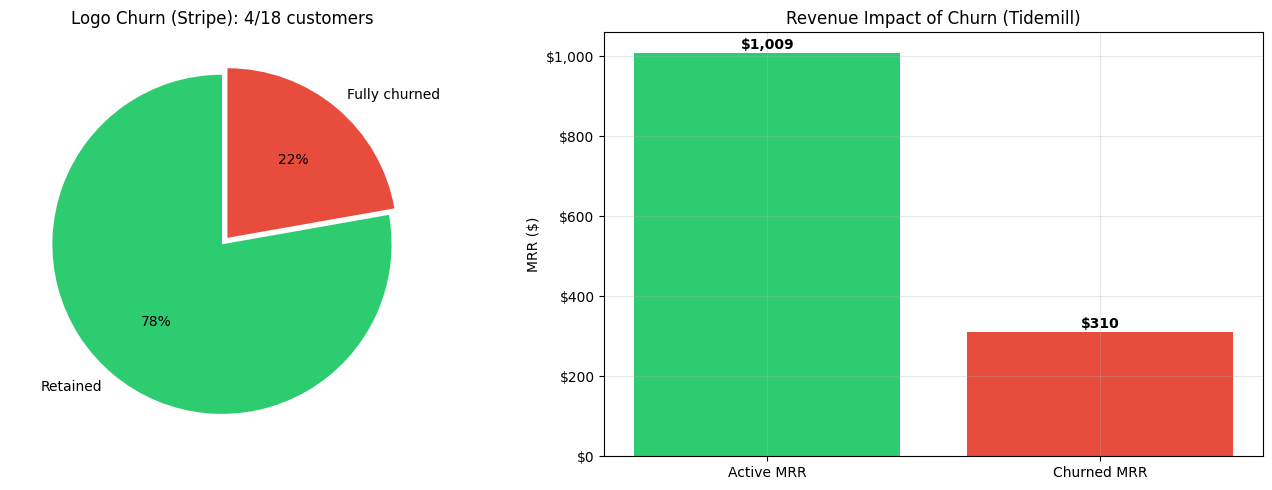

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logo churn pie: customer-level
axes[0].pie(
    [n_active - n_churned, n_churned],
    labels=["Retained", "Fully churned"],
    autopct="%1.0f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    explode=[0, 0.05],
)
axes[0].set_title(f"Logo Churn (Stripe): {n_churned}/{n_active} customers")

# Revenue churn bar: Tidemill MRR breakdown
churn_movement = [b for b in breakdown if b["movement_type"] == "churn"]
lost_from_api = abs(churn_movement[0]["amount_base"]) if churn_movement else 0
active_mrr = df[df.status == "active"].mrr_cents.sum()

axes[1].bar(
    ["Active MRR", "Churned MRR"],
    [active_mrr / 100, lost_from_api / 100],
    color=["#2ecc71", "#e74c3c"],
)
axes[1].set_title("Revenue Impact of Churn (Tidemill)")
axes[1].set_ylabel("MRR ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, v in enumerate([active_mrr / 100, lost_from_api / 100]):
    axes[1].text(i, v + 10, f"${v:,.0f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Churn events from Tidemill vs Stripe cancellations

In [5]:
# Compare: Stripe canceled subs vs Tidemill churn events
stripe_canceled_ids = set(canceled["id"])
churn_events = [b for b in breakdown if b["movement_type"] == "churn"]

print(f"Stripe canceled subscriptions:  {len(stripe_canceled_ids)}")
print(f"Tidemill churn events (MRR):    {len(churn_events)}")
print()
print("MRR movement summary from Tidemill:")
for b in breakdown:
    amt = b["amount_base"] / 100
    print(f"  {b['movement_type']:15s}  ${amt:>10,.2f}")

Stripe canceled subscriptions:  11
Tidemill churn events (MRR):    1

MRR movement summary from Tidemill:
  expansion        $    116.00
  contraction      $    -58.00
  new              $  1,219.33
  churn            $   -310.00


## 5. Monthly Churn Rate Timeline

Compute logo and revenue churn rates per month to visualize churn trends over time.

In [6]:
# Monthly churn rates from Tidemill API
# Start from October — September has no prior baseline for denominator
months = pd.date_range(CHURN_START, END, freq="MS")
monthly_churn = []
for i in range(len(months) - 1):
    s = months[i].strftime("%Y-%m-%d")
    e = months[i + 1].strftime("%Y-%m-%d")
    logo = api_get("/api/metrics/churn", start=s, end=e, type="logo")
    revenue = api_get("/api/metrics/churn", start=s, end=e, type="revenue")
    monthly_churn.append(
        {
            "month": months[i].strftime("%Y-%m"),
            "logo_churn": float(logo) if logo is not None else None,
            "revenue_churn": float(revenue) if revenue is not None else None,
        }
    )

df_mc = pd.DataFrame(monthly_churn)
print("Monthly churn rates:")
for _, row in df_mc.iterrows():
    logo = f"{row.logo_churn * 100:.1f}%" if row.logo_churn is not None else "N/A"
    rev = f"{row.revenue_churn * 100:.1f}%" if row.revenue_churn is not None else "N/A"
    print(f"  {row.month}:  logo={logo:>6s}   revenue={rev:>6s}")

Monthly churn rates:
  2025-10:  logo= 11.1%   revenue=  6.2%
  2025-11:  logo= 13.6%   revenue= 13.1%
  2025-12:  logo=  9.1%   revenue=  5.3%
  2026-01:  logo=  3.8%   revenue=  2.3%
  2026-02:  logo=  6.7%   revenue=  4.2%


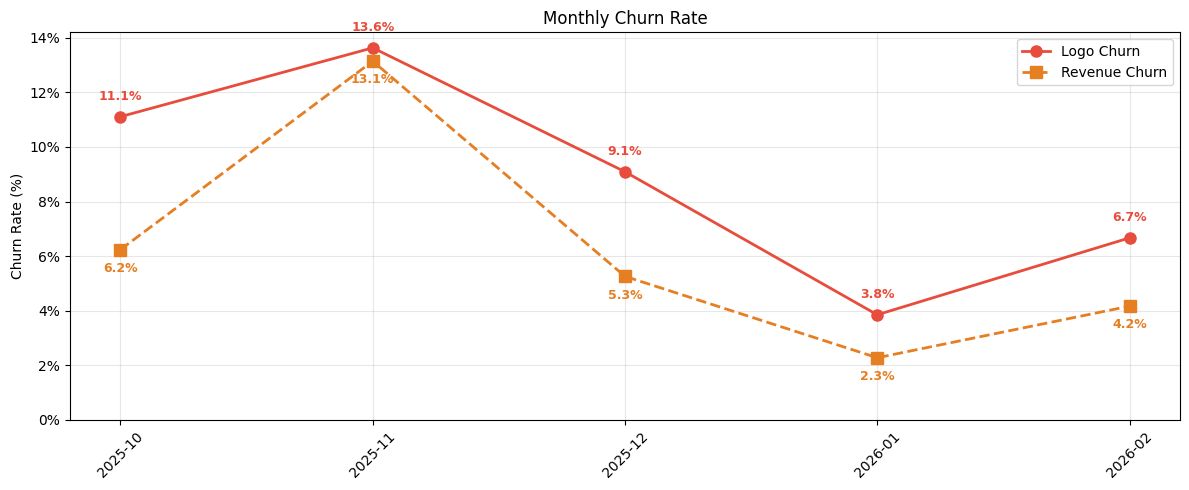

In [7]:
# Plot monthly churn rates
fig, ax = plt.subplots(figsize=(12, 5))

logo_vals = [r if r is not None else float("nan") for r in df_mc.logo_churn]
rev_vals = [r if r is not None else float("nan") for r in df_mc.revenue_churn]

x = range(len(df_mc))
ax.plot(
    x,
    [v * 100 for v in logo_vals],
    "o-",
    color="#e74c3c",
    linewidth=2,
    markersize=8,
    label="Logo Churn",
)
ax.plot(
    x,
    [v * 100 for v in rev_vals],
    "s--",
    color="#e67e22",
    linewidth=2,
    markersize=8,
    label="Revenue Churn",
)

for i, (lv, rv) in enumerate(zip(logo_vals, rev_vals, strict=True)):
    if not pd.isna(lv):
        ax.annotate(
            f"{lv * 100:.1f}%",
            (i, lv * 100),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontweight="bold",
            fontsize=9,
            color="#e74c3c",
        )
    if not pd.isna(rv):
        ax.annotate(
            f"{rv * 100:.1f}%",
            (i, rv * 100),
            textcoords="offset points",
            xytext=(0, -16),
            ha="center",
            fontweight="bold",
            fontsize=9,
            color="#e67e22",
        )

ax.set_xticks(x)
ax.set_xticklabels(df_mc.month, rotation=45)
ax.set_title("Monthly Churn Rate")
ax.set_ylabel("Churn Rate (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 6. Monthly Churned MRR

Lost MRR per month from the MRR waterfall — shows the dollar impact of churn over time.

/var/folders/7l/5vqmh87x0jz14rt2fznh6qpw0000gn/T/ipykernel_82527/3429831236.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_wf.month, rotation=45)


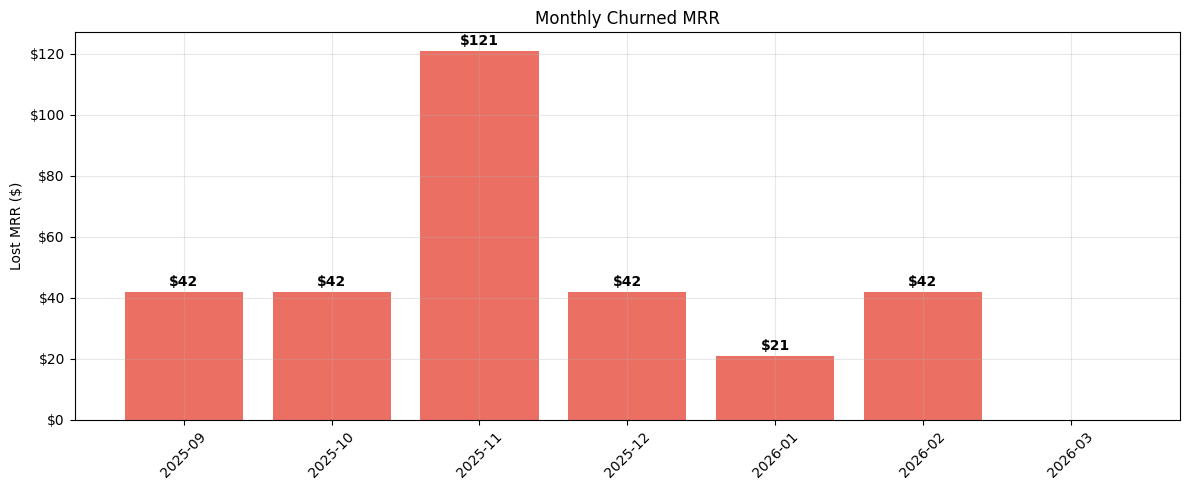


Total churned MRR: $310.00


In [8]:
# Monthly churned MRR from waterfall
waterfall = api_get("/api/metrics/mrr/waterfall", start=START, end=END)
df_wf = pd.DataFrame(waterfall)
df_wf["churn_dollars"] = df_wf["churn"].apply(lambda c: abs(c) / 100)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_wf.month, df_wf.churn_dollars, color="#e74c3c", alpha=0.8)

for bar, val in zip(bars, df_wf.churn_dollars, strict=True):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"${val:,.0f}",
            ha="center",
            fontweight="bold",
            fontsize=10,
        )

ax.set_title("Monthly Churned MRR")
ax.set_ylabel("Lost MRR ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_xticklabels(df_wf.month, rotation=45)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f"\nTotal churned MRR: ${df_wf.churn_dollars.sum():,.2f}")